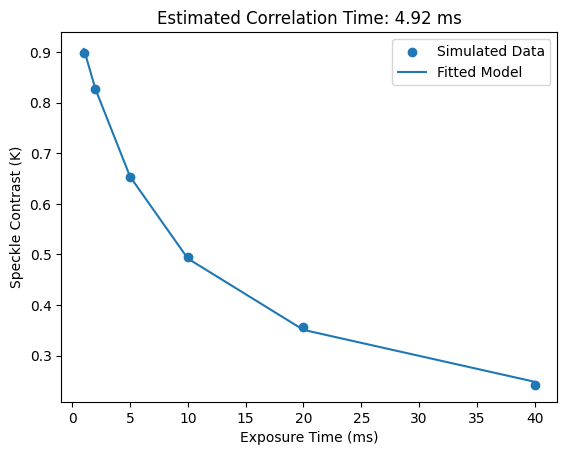

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ==============================
# MESI MODEL WITH DOWNLOAD
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# Create results folder
os.makedirs("results", exist_ok=True)

# Exposure times (seconds)
T = np.array([1, 2, 5, 10, 20, 40]) * 1e-3

# True correlation time (flow parameter)
tau_c_true = 5e-3

# MESI model
def mesi_model(T, tau_c):
    return np.sqrt(tau_c / (2*T) * (1 - np.exp(-2*T/tau_c)))

# Simulated noisy data
K_true = mesi_model(T, tau_c_true)
noise = np.random.normal(0, 0.01, len(T))
K_noisy = K_true + noise

# Curve fitting
popt, _ = curve_fit(mesi_model, T, K_noisy)
tau_c_est = popt[0]

# Plot
plt.figure()
plt.scatter(T*1000, K_noisy, label="Simulated Data")
plt.plot(T*1000, mesi_model(T, tau_c_est), label="Fitted Model")
plt.xlabel("Exposure Time (ms)")
plt.ylabel("Speckle Contrast (K)")
plt.title(f"Estimated Correlation Time: {tau_c_est*1000:.2f} ms")
plt.legend()

# Save figure
plt.savefig("results/mesi_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Download file (Colab)
from google.colab import files
files.download("results/mesi_curve.png")